Topic pref

In [ ]:
import pandas as pd

prf = pd.read_csv("pr_F.csv")
prm = pd.read_csv("pr_M.csv")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
top_f = prf.sort_values('pr', ascending=False).head(15)
top_m = prm.sort_values('pr', ascending=False).head(15)
bot_f = prf.sort_values('pr', ascending=False).tail(15)
bot_m = prm.sort_values('pr', ascending=False).tail(15)
f_ranks = {t: r for t, r in zip(prf["topic"], prf["pr"].rank(ascending=False).astype(int))}
m_ranks = {t: r for t, r in zip(prm["topic"], prm["pr"].rank(ascending=False).astype(int))}

for ax, df_f, df_m, title in [
    (ax1, top_f, top_m, "Top"),
    (ax2, bot_f, bot_m, "Bottom"),
]:
    # keep each gender's own top 10, no union
    f_topics = df_f["topic"].values
    m_topics = df_m["topic"].values

    f = prf.set_index("topic").reindex(f_topics)["pr"]
    m = prm.set_index("topic").reindex(m_topics)["pr"]

    # combined y = union but plot only where each gender has data
    y = list(dict.fromkeys(list(f_topics) + list(m_topics)))  # preserve order, no duplicates
    
    f_vals = prf.set_index("topic").reindex(y)["pr"]  # NaN where not in top 10
    m_vals = prm.set_index("topic").reindex(y)["pr"]  # NaN where not in top 10

    for j, topic in enumerate(y):
        fval = f_vals[topic]
        mval = m_vals[topic]
        if not pd.isna(fval):
            ax.barh(j, fval, color="coral", label="Female" if j==0 else "")
            ax.text(fval/2, j, str(f_ranks.get(topic, "")), ha="center", va="center", fontsize=12, color="white", fontweight="bold")
        if not pd.isna(mval):
            ax.barh(j, -mval, color="steelblue", label="Male" if j==0 else "")
            ax.text(-mval/2, j, str(m_ranks.get(topic, "")), ha="center", va="center", fontsize=12, color="white", fontweight="bold")

    ax.set_yticks(range(len(y)))
    ax.set_yticklabels(y, fontsize=12)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("PR")
    ax.set_title(title)
    ax.invert_yaxis()
    ax.legend()

plt.tight_layout()
plt.show()

Gender

In [3]:
import duckdb

# only reads these 3 columns from disk, regardless of how many columns the parquet has
a2t = duckdb.sql("""
    SELECT authors, year, id, gender, cohort
    FROM 'a2t_dec_final.parquet'
""").df()

In [4]:
import pandas as pd


# share of women authors per (cohort, year)
share_by_cohort_year = (
    a2t.groupby(["cohort", "year"])["gender"]
    .apply(lambda s: (s == "F").mean())
    .reset_index(name="share_women")
)

# each cohort's overall baseline share of women (across all years)
cohort_baseline = (
    a2t.groupby("cohort")["gender"]
    .apply(lambda s: (s == "F").mean())
    .reset_index(name="cohort_baseline_share")
)

# merge and compute the ratio
share_by_cohort_year = share_by_cohort_year.merge(cohort_baseline, on="cohort")
share_by_cohort_year["ratio"] = (
    share_by_cohort_year["share_women"] / share_by_cohort_year["cohort_baseline_share"]
)

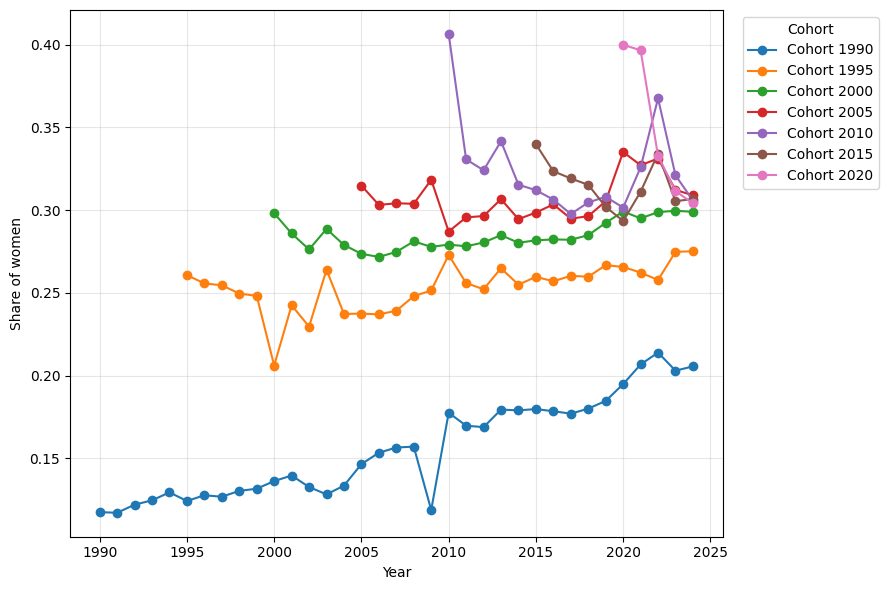

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
 
for cohort, group in share_by_cohort_year.groupby("cohort"):
    group = group.sort_values("year")
    ax.plot(group["year"], group["share_women"], marker="o", label=f"Cohort {cohort}")
 
#ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
 
ax.set_xlabel("Year")
ax.set_ylabel("Share of women")
ax.legend(title="Cohort", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.3)
 
fig.tight_layout()
fig.savefig("women_share_ratio_by_cohort.png", dpi=150)
plt.show()

gender x metric

In [1]:
import duckdb

# only reads these 3 columns from disk, regardless of how many columns the parquet has
a2t = duckdb.sql("""
    SELECT authors, year, cohort, gender, gini_field, share_3, prod_3, cite_3, career_age
    FROM 'a2t_dec_final.parquet'
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

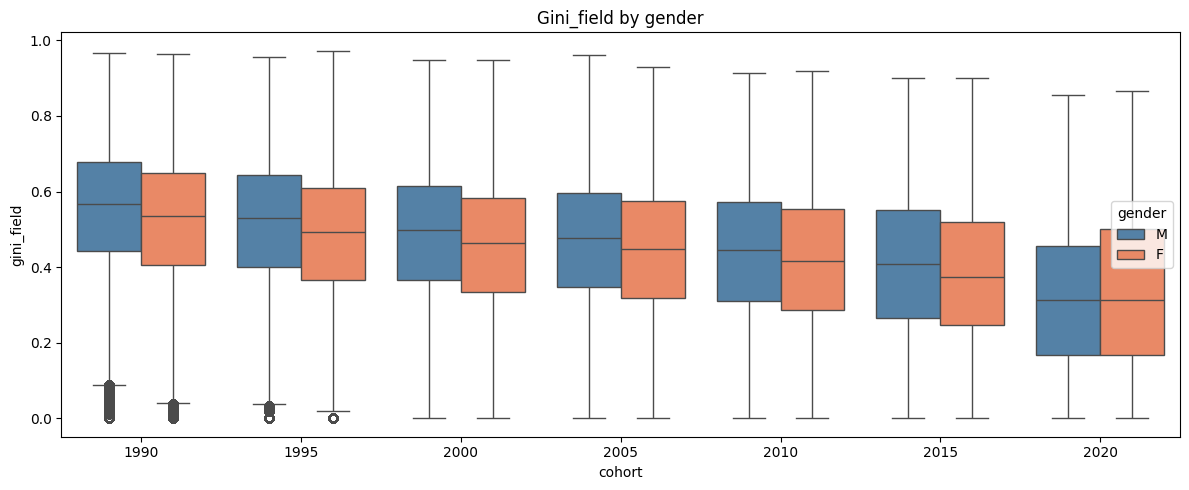

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(12, 5))

sns.boxplot(data=a2t, x="cohort", y="gini_field", hue="gender", ax=axes, palette=["steelblue","coral"])
axes.set_title("Gini_field by gender")


plt.tight_layout()
plt.show()

C:\Users\cumun\AppData\Local\Temp\ipykernel_24960\3715307473.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\cumun\Documents\ENSAE\AI Internship\AI\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


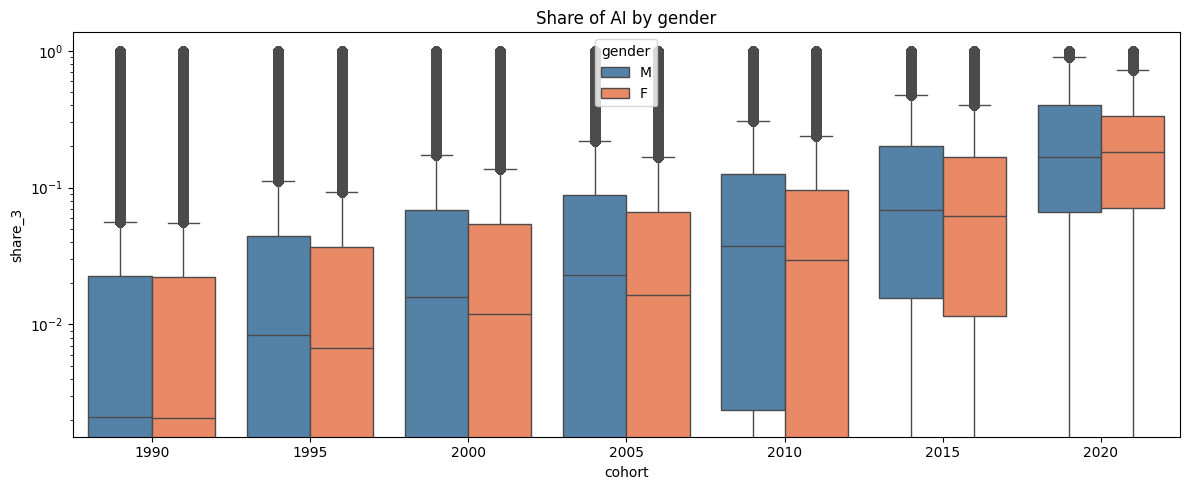

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(12, 5))

sns.boxplot(data=a2t, x="cohort", y="share_3", hue="gender", ax=axes, palette=["steelblue","coral"])
axes.set_title("Share of AI by gender")
axes.set_yscale("log")


plt.tight_layout()
plt.show()

C:\Users\cumun\AppData\Local\Temp\ipykernel_24960\286272096.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\cumun\Documents\ENSAE\AI Internship\AI\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


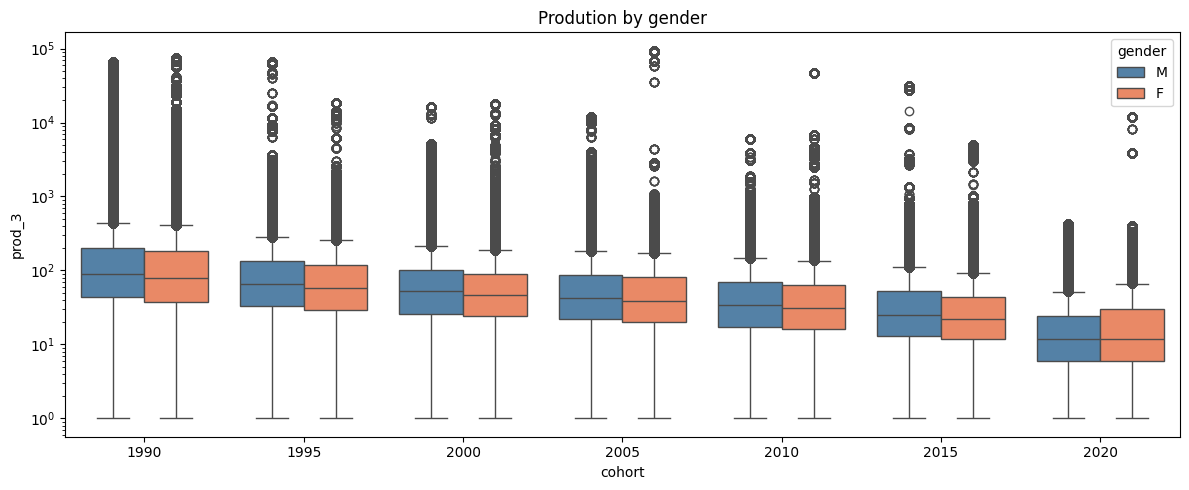

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(12, 5))

sns.boxplot(data=a2t, x="cohort", y="prod_3", hue="gender", ax=axes, palette=["steelblue","coral"])
axes.set_title("Prodution by gender")
axes.set_yscale("log")


plt.tight_layout()
plt.show()

C:\Users\cumun\AppData\Local\Temp\ipykernel_24960\2544270617.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\cumun\Documents\ENSAE\AI Internship\AI\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


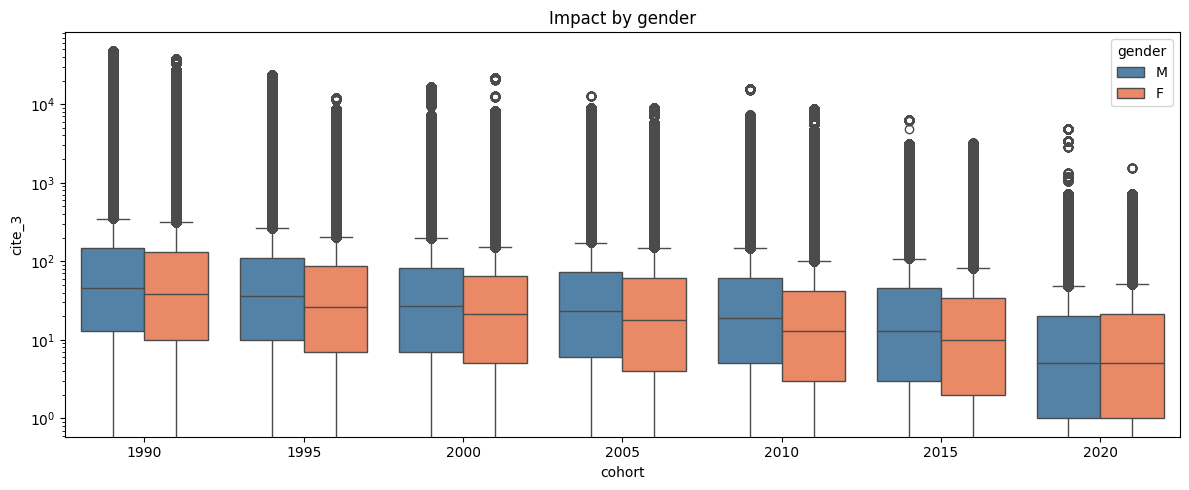

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(12, 5))

sns.boxplot(data=a2t, x="cohort", y="cite_3", hue="gender", ax=axes, palette=["steelblue","coral"])
axes.set_title("Impact by gender")
axes.set_yscale("log")

plt.tight_layout()
plt.show()

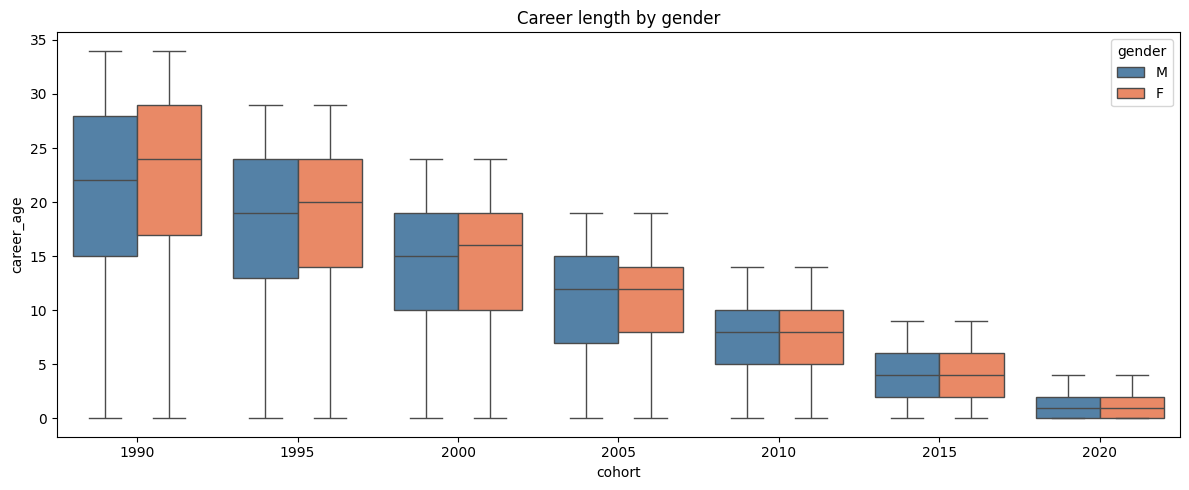

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(12, 5))

sns.boxplot(data=a2t, x="cohort", y="career_age", hue="gender", ax=axes, palette=["steelblue","coral"])
axes.set_title("Career length by gender")


plt.tight_layout()
plt.show()